## Destek Vektör Regresyonu (Lineer) Model

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from warnings import filterwarnings
filterwarnings('ignore')

In [47]:
hit = pd.read_csv("hitters.csv")
df = hit.copy()
df = df.dropna()
dms = pd.get_dummies(df[["League", "Division", "NewLeague"]])
dms = dms.astype(int)
y = df["Salary"]
X_ = df.drop(["Salary", "League", "Division", "NewLeague"], axis = 1).astype("float64")
X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size = 0.25,
                                                    random_state = 42)

*SVR performansını lineer regresyon ile karşılaştıracağız. Bu yüzden train ve test seti içerisinden bir bağımsız değişken seçimi gerçekleştirmemiz gerekiyor. Bağımlı Değişkenimiz aynı ve Salary. Yani Salary ve Hits arasındaki ilişkiyi lineer regresyon ve basit SVR bazında değerlendirmesini yapacağız.*

In [3]:
X_train = pd.DataFrame(X_train["Hits"])
X_test = pd.DataFrame(X_test["Hits"])

In [4]:
#basit svr model

In [5]:
from sklearn.svm import SVR

In [6]:
svr_model = SVR(kernel = "linear").fit(X_train, y_train)

In [7]:
svr_model.predict(X_train)[0:5]

array([403.52804878, 666.91219512, 706.66829268, 194.80853659,
       423.40609756])

In [8]:
#model denklemi

In [9]:
print("y = {0} + {1} x".format(svr_model.intercept_[0],
                             svr_model.coef_[0] [0]))

y = -48.69756097561513 + 4.969512195122206 x


In [10]:
X_train["Hits"][0:1]

183    91.0
Name: Hits, dtype: float64

In [11]:
-48.69756097561513 +  4.969512195122206 * 91

403.5280487805056

In [12]:
y_pred = svr_model.predict(X_train)

In [13]:
#grafik

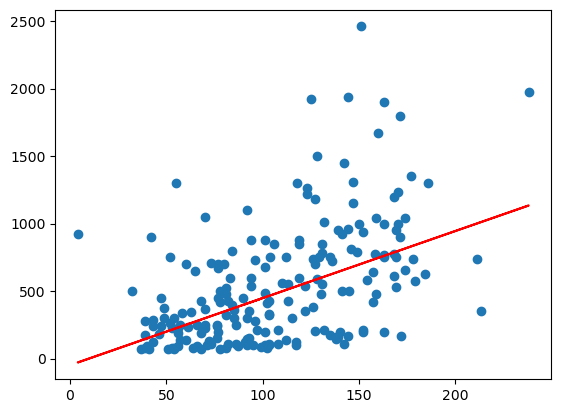

In [14]:
plt.scatter(X_train, y_train)
plt.plot(X_train, y_pred, color = 'r');

In [15]:
#dogrusal regresyon

In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
lm_model = LinearRegression().fit(X_train, y_train)
lm_pred = lm_model.predict(X_train)
print("y = {0} + {1} x".format(lm_model.intercept_,
                             svr_model.coef_[0]))

y = -8.814095480334345 + [4.9695122] x


In [18]:
-8.814095480334345 + 4.9695122*91

443.4115147196656

In [19]:
#iki modelin karşılaştırılması

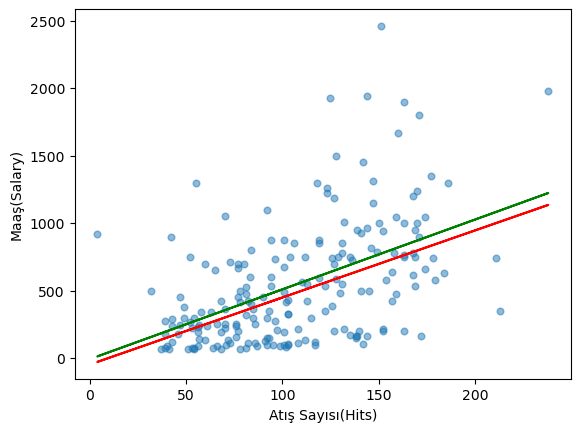

In [20]:
plt.scatter(X_train, y_train, alpha = 0.5, s = 23)
plt.plot(X_train, lm_pred, color = 'g')
plt.plot(X_train, y_pred, color = 'r')

plt.xlabel("Atış Sayısı(Hits)")
plt.ylabel("Maaş(Salary)")
plt.show();

*Yeşil olan Lineer Regesyon modeline ait. Yani Lineer Regresyon ile daha büyük değerler alırız. Neden ? Çünkü Lineer Regresyon'nun aykırı değerlere olan duyarlılığı SVR'ye göre daha fazladır. SVR'nin aykırılığa karşı dayanıklılığı daha fazladır. Bu yüzden SVR modele **Roubust Model** de denir.*

## Tahmin

In [21]:
print("y = {0} + {1} x".format(svr_model.intercept_[0],
                             svr_model.coef_[0] [0]))

y = -48.69756097561513 + 4.969512195122206 x


In [22]:
svr_model.predict([[91]])

array([403.52804878])

In [23]:
#test hatasi

In [24]:
y_pred = svr_model.predict(X_test)

In [25]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(459.0187960365147)

## Model Tuning

In [27]:
svr_model.get_params()

{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'epsilon': 0.1,
 'gamma': 'scale',
 'kernel': 'linear',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [48]:
svr_params = {"C": np.arange(0.1,2,0.1)}
svr_cv_model = GridSearchCV(svr_model, svr_params, cv = 10).fit(X_train, y_train)

In [40]:
pd.Series(svr_cv_model.best_params_).iloc[0]

np.float64(0.1)

In [51]:
svr_tuned = SVR(kernel = "linear", 
                C = pd.Series(svr_cv_model.best_params_).iloc[0]).fit(X_train, y_train)

In [43]:
#tune edilmiş modelin test hatası

In [44]:
y_pred = svr_tuned.predict(X_test)

In [46]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(458.198966781116)

*Bu basit svr modelin test hatası yani tek bir değişken ile eğitilen model. Eğitim ve test verisini bir bütün olarak eğitilen modelin test hatasını da bulalım.*

*Yukarıda modeli bütün değişkenleri kullanarak tekrar eğittim. Yaklaşık 10 dk sürdü bu işlem.*

In [49]:
pd.Series(svr_cv_model.best_params_).iloc[0]

np.float64(0.4)

In [52]:
y_pred = svr_tuned.predict(X_test)

In [54]:
# bütün değişkenler ile yapılan test hatasi

In [53]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(367.538528365296)

### Buradan Ne Sonuç Çıkarırız ?

*Tek bir değişken ile eğittiğimiz modelin hata miktarı daha fazla. Daha fazla değişken işin içine girdiğinde bu hata miktarı ciddi bir miktarda azalıyor. Bu da veri setindeki diğer değişkenlerin bağımlı değişkenin değişkenliğini iyi bir şekilde açıklayabildiği anlamına geliyor.*